<a href="https://colab.research.google.com/github/prab369/Tabuler_data_classification/blob/main/Tabuler_data_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: prab369
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification


100%|██████████| 888k/888k [00:00<00:00, 163MB/s]

In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)


cuda


In [3]:
df= pd.read_csv("/content/rice-type-classification/riceClassification.csv")
df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [4]:
df.dropna(inplace = True)
df.drop(['id'], axis=1, inplace= True)
print(df.shape)


(18185, 11)


In [5]:
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [6]:
print(df["Class"].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [7]:
original_df = df.copy()

for column in df.columns:
  df[column]=df[column]/df[column].abs().max()
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [8]:
X= np.array(df.iloc[:,:-1])#all row and columns except last one
Y=np.array(df.iloc[:,-1])#only last coloum and row

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size = 0.3)

In [10]:
X_test,X_val,y_test,y_val = train_test_split(X_test,y_test,test_size = 0.5)

In [11]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(12729, 10)
(2728, 10)
(2728, 10)


In [12]:
class dataset(Dataset):
  def __init__(self,X,Y):
    self.X= torch.tensor(X, dtype=torch.float32).to(device)
    self.Y= torch.tensor(Y, dtype=torch.float32).to(device)
  def __len__(self):
    return len(self.X)
  def __getitem__(self,index):
    return self.X[index], self.Y[index]


In [13]:
training_data= dataset(X_train, y_train)
validation_data= dataset(X_val,y_val)
testing_data= dataset(X_test, y_test)

In [14]:
train_dataloader = DataLoader(training_data, batch_size= 32, shuffle = True)
validation_dataloader = DataLoader(validation_data, batch_size= 32, shuffle = True)
testing_dataloader = DataLoader(testing_data, batch_size= 32, shuffle = True)

In [15]:
for x,y in train_dataloader:
  print(x)
  print("===")
  print(y)
  break

tensor([[0.9246, 0.8828, 0.9108, 0.9158, 0.8780, 0.9616, 0.7053, 0.7638, 0.8693,
         0.5499],
        [0.8591, 0.8630, 0.8639, 0.9232, 0.8171, 0.9269, 0.7834, 0.7415, 0.8569,
         0.5667],
        [0.9682, 0.9058, 0.9355, 0.9155, 0.9334, 0.9840, 0.6686, 0.8019, 0.8256,
         0.5493],
        [0.5252, 0.7847, 0.5852, 0.9742, 0.4995, 0.7247, 0.5738, 0.6288, 0.7285,
         0.7607],
        [0.8644, 0.8371, 0.8992, 0.9051, 0.8329, 0.9298, 0.7227, 0.7502, 0.8424,
         0.5281],
        [0.6273, 0.8870, 0.6201, 0.9817, 0.5977, 0.7920, 0.5891, 0.7034, 0.6953,
         0.8116],
        [0.6460, 0.8461, 0.6721, 0.9659, 0.6118, 0.8038, 0.9296, 0.6847, 0.7557,
         0.7143],
        [0.6329, 0.8629, 0.6437, 0.9742, 0.6037, 0.7956, 0.6754, 0.6989, 0.7106,
         0.7606],
        [0.6288, 0.8507, 0.6517, 0.9708, 0.5997, 0.7930, 0.6208, 0.6943, 0.7153,
         0.7406],
        [0.6777, 0.7512, 0.7867, 0.9120, 0.6442, 0.8232, 0.7095, 0.6523, 0.8734,
         0.5417],
        [0

In [16]:
HIDDEN_NEURONS = 10
class MyModel(nn.Module):
  def __init__(self):
    super(MyModel,self).__init__()
    self.input_layer = nn.Linear(X.shape[1],HIDDEN_NEURONS)
    self.linear = nn.Linear(HIDDEN_NEURONS,1)
    self.sigmoid= nn.Sigmoid()

  def forward(self,x):
    x= self.input_layer(x)
    x=self.linear(x)
    x=self.sigmoid(x)
    return x

model= MyModel().to(device)

In [17]:
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [18]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(),lr = 1e-3)

In [19]:
from IPython.lib.pretty import Breakable
total_loss_train_plot=[]
total_loss_validation_plot=[]
total_acc_train_plot= []
total_acc_validation_plot = []

epochs= 10
for epoch in range(epochs):
  total_acc_train = 0
  total_loss_train=0
  total_acc_val = 0
  total_loss_val=0

  for data in train_dataloader:
    inputs, labels = data
    prediction = model(inputs).squeeze(1)
    batch_loss = criterion(prediction, labels)
    total_loss_train+= batch_loss.item()
    acc = ((prediction).round()== labels).sum().item()
    total_acc_train +=acc
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for data in validation_dataloader:
      inputs, labels = data
      prediction = model(inputs).squeeze(1)
      batch_loss = criterion(prediction, labels)
      total_loss_val +=batch_loss.item()
      acc = ((prediction).round()== labels).sum().item()
      total_acc_val += acc
  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(training_data.__len__())*100, 4))
  total_acc_validation_plot.append(round(total_acc_val/(validation_data.__len__())*100, 4))
  print(f'''Epoch no. {epoch+1} Train Loss:{round(total_loss_train/1000,4)} Train Accuracy {round(total_acc_train/training_data.__len__()*100,4)} Validation Loss:{round(total_loss_val/1000,4)} Validation Accuracy:{round(total_acc_val/validation_data.__len__()*100,4)}''')



Epoch no. 1 Train Loss:0.2384 Train Accuracy 84.7435 Validation Loss:0.0386 Validation Accuracy:96.4076
Epoch no. 2 Train Loss:0.1181 Train Accuracy 98.0203 Validation Loss:0.0161 Validation Accuracy:97.9106
Epoch no. 3 Train Loss:0.0555 Train Accuracy 98.2717 Validation Loss:0.0092 Validation Accuracy:98.827
Epoch no. 4 Train Loss:0.0358 Train Accuracy 98.4366 Validation Loss:0.0066 Validation Accuracy:98.7537
Epoch no. 5 Train Loss:0.0275 Train Accuracy 98.5466 Validation Loss:0.0053 Validation Accuracy:98.7903
Epoch no. 6 Train Loss:0.0234 Train Accuracy 98.5938 Validation Loss:0.0047 Validation Accuracy:98.7903
Epoch no. 7 Train Loss:0.0209 Train Accuracy 98.6095 Validation Loss:0.0043 Validation Accuracy:98.8636
Epoch no. 8 Train Loss:0.0194 Train Accuracy 98.6173 Validation Loss:0.0041 Validation Accuracy:98.8636
Epoch no. 9 Train Loss:0.0184 Train Accuracy 98.633 Validation Loss:0.0039 Validation Accuracy:98.9003
Epoch no. 10 Train Loss:0.0177 Train Accuracy 98.688 Validation Lo

In [20]:

with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for data in testing_dataloader:
    inputs, labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss_test = criterion((prediction), labels)
    total_loss_test += batch_loss_test.item()
    acc = ((prediction).round() == labels).sum().item()
    total_acc_test += acc

print(f"Accuracy Score is: {round((total_acc_test/X_test.shape[0])*100, 2)}%")

Accuracy Score is: 98.35%


In [21]:
print("total_acc_test =", total_acc_test)
print("X_test.shape[0] =", X_test.shape[0])

total_acc_test = 2683
X_test.shape[0] = 2728


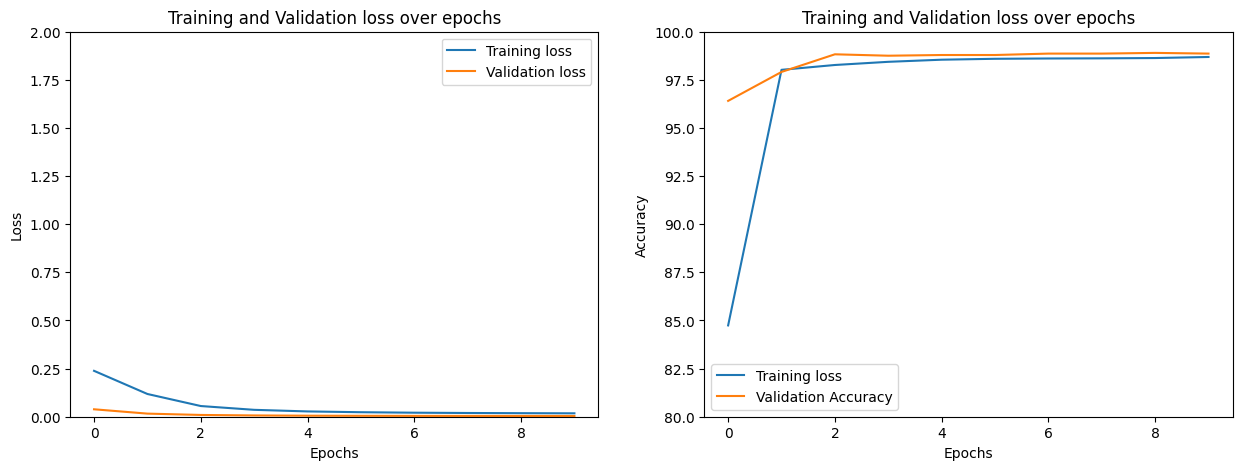

In [22]:
fig, axes= plt.subplots(nrows=1, ncols=2, figsize=(15,5))
axes[0].plot(total_loss_train_plot, label= 'Training loss')
axes[0].plot(total_loss_validation_plot, label= 'Validation loss')
axes[0].set_title("Training and Validation loss over epochs")
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_ylim([0,2])
axes[0].legend()

axes[1].plot(total_acc_train_plot, label= 'Training loss')
axes[1].plot(total_acc_validation_plot, label= 'Validation Accuracy')
axes[1].set_title("Training and Validation loss over epochs")
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([80,100])
axes[1].legend()

plt.show()

In [23]:
area = float(input("Area: "))/original_df['Area'].abs().max()
MajorAxisLength = float(input("Major Axis Length: "))/original_df['MajorAxisLength'].abs().max()
MinorAxisLength = float(input("Minor Axis Length: "))/original_df['MinorAxisLength'].abs().max()
Eccentricity = float(input("Eccentricity: "))/original_df['Eccentricity'].abs().max()
ConvexArea = float(input("Convex Area: "))/original_df['ConvexArea'].abs().max()
EquivDiameter = float(input("EquivDiameter: "))/original_df['EquivDiameter'].abs().max()
Extent = float(input("Extent: "))/original_df['Extent'].abs().max()
Perimeter = float(input("Perimeter: "))/original_df['Perimeter'].abs().max()
Roundness = float(input("Roundness: "))/original_df['Roundness'].abs().max()
AspectRation = float(input("AspectRation: "))/original_df['AspectRation'].abs().max()

my_inputs = [area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, AspectRation]

print("="*20)
model_inputs = torch.Tensor(my_inputs).to(device)
prediction = (model(model_inputs))
print(prediction)
print("Class is: ", round(prediction.item()))

Area: 6431.279
Major Axis Length: 145.21338
Minor Axis Length: 56.902
Eccentricity: 0.919981821
Convex Area: 6518.93759999
EquivDiameter: 90.483541
Extent: 0.8506668
Perimeter:  329.972
Roundness: 0.742255516
AspectRation: 2.551696
tensor([0.7803], device='cuda:0', grad_fn=<SigmoidBackward0>)
Class is:  1
